# Weld Quality – Exploratory Data Analysis

Source: [welddb](http://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html), a public weld database (chemical composition, welding process parameters, mechanical properties, microstructure).

**Goal of this notebook**: understand the structure of the raw file, assess data quality (censored values, mixed units) and target variable availability before defining a preprocessing / modeling strategy.


## 1. Loading and column typing

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Figures are saved under figures/exploration/<section>/, one subfolder per section
FIGURES_DIR = Path("/Users/aureliendelest/Documents/git/weld-quality-pred/figures/exploration")
FIGURE_SUBDIRS = {
    "missingness": FIGURES_DIR / "01_missingness",
    "targets": FIGURES_DIR / "02_targets",
    "distributions": FIGURES_DIR / "03_distributions",
    "correlations": FIGURES_DIR / "04_correlations",
}
for path in FIGURE_SUBDIRS.values():
    path.mkdir(parents=True, exist_ok=True)

columns = [
    # Chemical composition (weight %)
    "c_conc_wt", "si_conc_wt", "mn_conc_wt", "s_conc_wt",
    "p_conc_wt", "ni_conc_wt", "cr_conc_wt", "mo_conc_wt",
    "v_conc_wt", "cu_conc_wt", "co_conc_wt", "w_conc_wt",
    # Chemical composition (ppm by weight)
    "o_conc_ppm", "ti_conc_ppm", "n_conc_ppm", "al_conc_ppm", "b_conc_ppm",
    "nb_conc_ppm", "sn_conc_ppm", "as_conc_ppm", "sb_conc_ppm",
    # Welding process parameters
    "current_a", "voltage_v", "current_type", "electrode_polarity",
    "heat_input_kj_mm", "interpass_temp_c", "weld_type",
    "pwht_temp_c", "pwht_time_h",
    # Mechanical properties
    "yield_strength_mpa", "uts_mpa", "elongation_pct", "reduction_of_area_pct",
    "charpy_temp_c", "charpy_toughness_j", "hardness_kgf_mm2", "fatt50_temp_c",
    # Microstructure (%)
    "primary_ferrite_pct", "ferrite_second_phase_pct", "acicular_ferrite_pct",
    "martensite_pct", "ferrite_carbide_aggregate_pct",
    # Identifier
    "weld_id",
]

df = pd.read_csv(
    "/Users/aureliendelest/Documents/git/weld-quality-pred/data/welddb.data",
    sep=r"\s+",            # one or more whitespace characters
    header=None,
    names=columns,
    na_values="N",
)

print(df.shape)
print(df.dtypes.value_counts(), "\n")

# Numeric columns that were parsed as text
expected_text_columns = ["current_type", "electrode_polarity", "weld_type", "weld_id"]
suspicious = [c for c in df.columns
              if not pd.api.types.is_numeric_dtype(df[c]) and c not in expected_text_columns]
print("Numeric columns parsed as text:", suspicious, "\n")

# For each one, show the values that cannot be converted to numbers
for c in suspicious:
    values = df[c].dropna()
    non_numeric = values[pd.to_numeric(values, errors="coerce").isna()]
    print(f"{c}: {non_numeric.nunique()} distinct non-numeric values ->",
          non_numeric.unique()[:15])

(1652, 44)
float64    23
str        21
Name: count, dtype: int64 

Numeric columns parsed as text: ['s_conc_wt', 'mo_conc_wt', 'v_conc_wt', 'cu_conc_wt', 'co_conc_wt', 'w_conc_wt', 'ti_conc_ppm', 'n_conc_ppm', 'al_conc_ppm', 'b_conc_ppm', 'nb_conc_ppm', 'sn_conc_ppm', 'as_conc_ppm', 'sb_conc_ppm', 'interpass_temp_c', 'hardness_kgf_mm2', 'primary_ferrite_pct'] 

s_conc_wt: 1 distinct non-numeric values -> <StringArray>
['<0.002']
Length: 1, dtype: str
mo_conc_wt: 1 distinct non-numeric values -> <StringArray>
['<0.01']
Length: 1, dtype: str
v_conc_wt: 4 distinct non-numeric values -> <StringArray>
['<0.0005', '<0.01', '<0.005', '<5']
Length: 4, dtype: str
cu_conc_wt: 1 distinct non-numeric values -> <StringArray>
['<0.01']
Length: 1, dtype: str
co_conc_wt: 1 distinct non-numeric values -> <StringArray>
['<0.01']
Length: 1, dtype: str
w_conc_wt: 1 distinct non-numeric values -> <StringArray>
['<0.1']
Length: 1, dtype: str
ti_conc_ppm: 4 distinct non-numeric values -> <StringArray>
['<5',

**Finding.** 21 columns expected to be numeric are loaded as text because of lab notation conventions: values below detection limit (`<0.01`), ranges (`150-200`), mixed hardness scales (`Hv10` vs `Hv30`), and composite codes for nitrogen (`67tot33res`). These columns will need dedicated cleaning before modeling (extract the numeric value, keep a "censored" flag, split out the hardness scale).

## 2. Missing values

### 2.1 Missing rate per variable

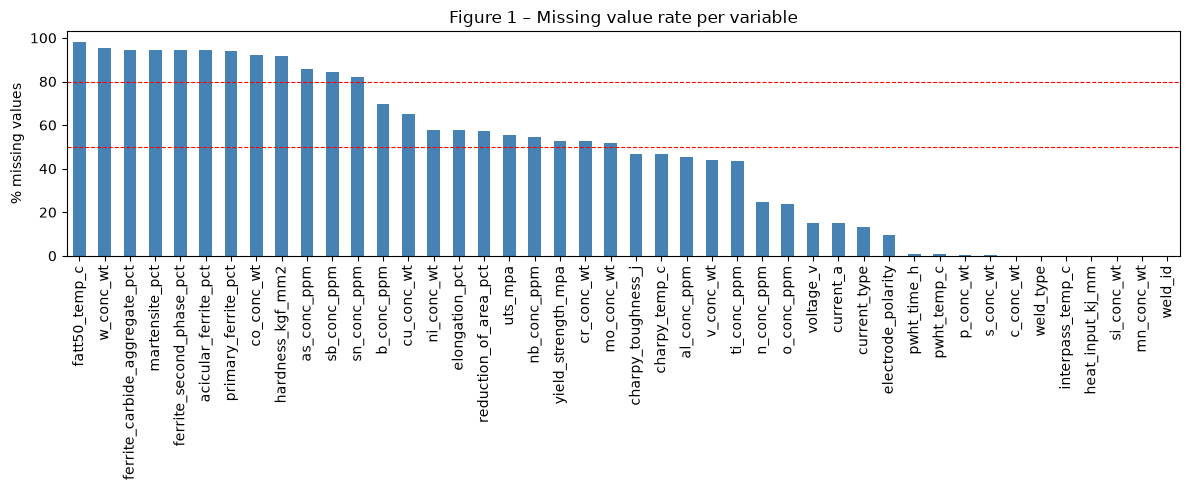

fatt50_temp_c                    98.1
w_conc_wt                        95.5
ferrite_carbide_aggregate_pct    94.6
martensite_pct                   94.6
ferrite_second_phase_pct         94.6
acicular_ferrite_pct             94.6
primary_ferrite_pct              94.1
co_conc_wt                       92.2
hardness_kgf_mm2                 91.6
as_conc_ppm                      85.8
sb_conc_ppm                      84.3
sn_conc_ppm                      82.1
b_conc_ppm                       69.5
cu_conc_wt                       65.0
ni_conc_wt                       57.8
elongation_pct                   57.6
reduction_of_area_pct            57.3
uts_mpa                          55.3
nb_conc_ppm                      54.5
yield_strength_mpa               52.8
cr_conc_wt                       52.5
mo_conc_wt                       52.0
charpy_toughness_j               46.8
charpy_temp_c                    46.8
al_conc_ppm                      45.2
v_conc_wt                        43.8
ti_conc_ppm 

In [2]:
import matplotlib.pyplot as plt

missing_rate = df.isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(12, 5))
missing_rate.plot.bar(ax=ax, color="steelblue")
ax.set_ylabel("% missing values")
ax.set_title("Figure 1 – Missing value rate per variable")
for threshold in (50, 80):                     # thresholds to discuss
    ax.axhline(threshold, color="red", linestyle="--", linewidth=0.8)
plt.tight_layout()
fig.savefig(FIGURE_SUBDIRS["missingness"] / "fig1_missing_rate_per_variable.png", dpi=150)
plt.show()

print(missing_rate.round(1).to_string())

**Finding.** A core set of variables is almost always populated (base composition C/Si/Mn, `weld_type`, `interpass_temp_c`, `heat_input_kj_mm`). Conversely, microstructure (`primary_ferrite_pct`, `martensite_pct`, ...), `fatt50_temp_c`, and several trace elements exceed 90% missing: barely usable as-is.

### 2.2 Structure of missingness (matrix and nullity correlation)

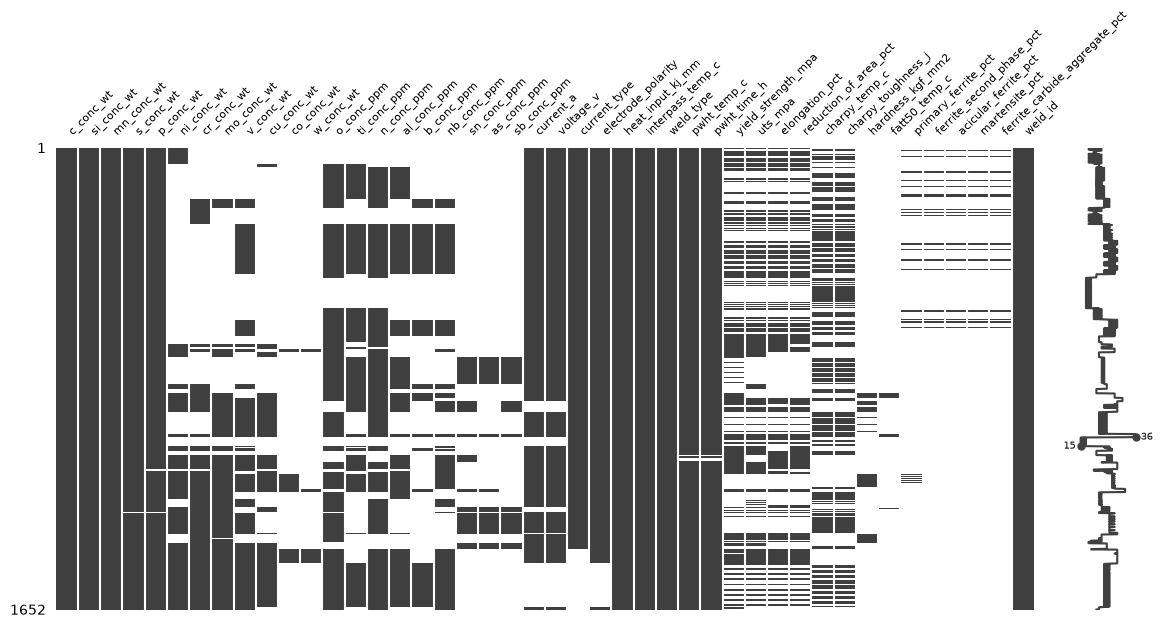

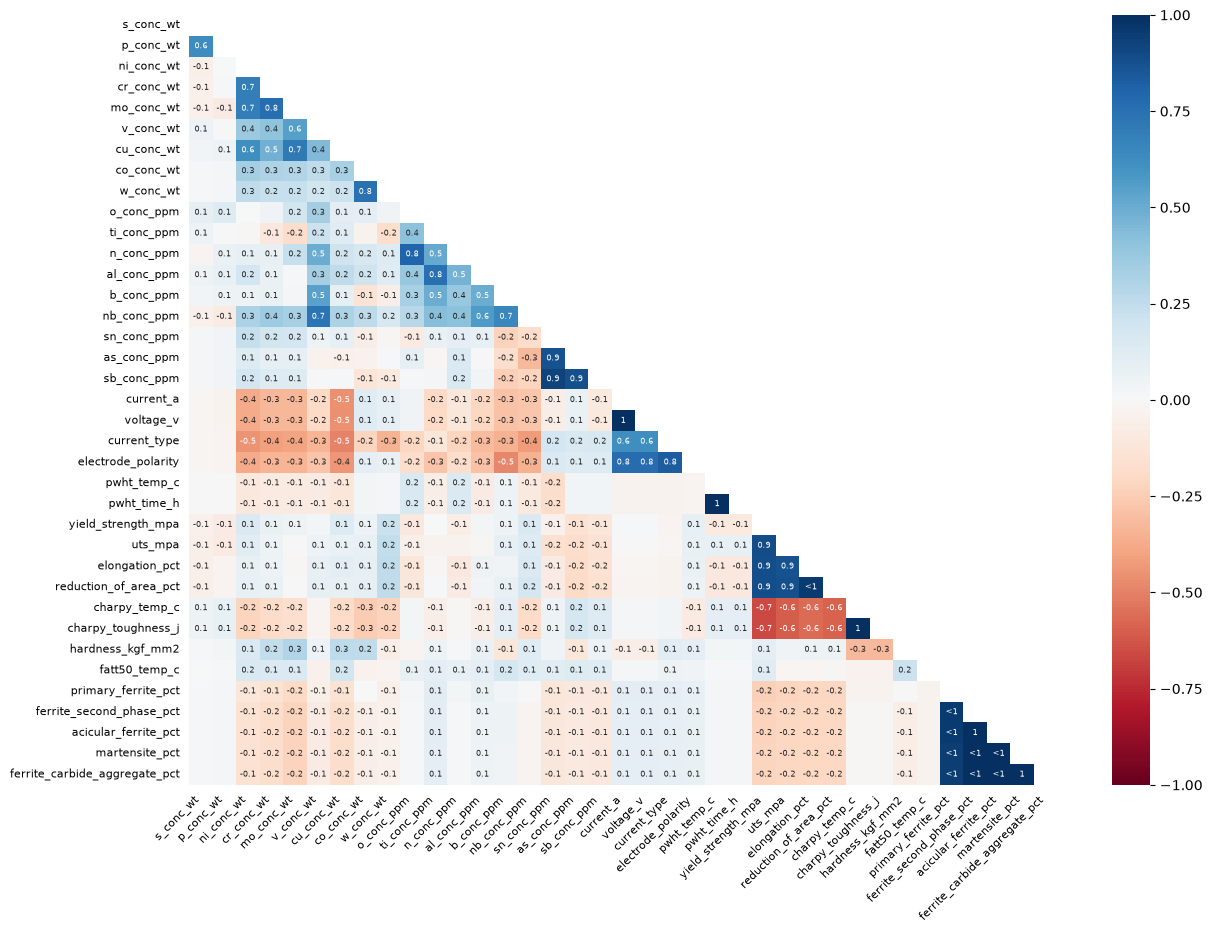

In [3]:
import missingno as msno

ax = msno.matrix(df, figsize=(14, 6), fontsize=8)   # rows = welds, white = missing
ax.get_figure().savefig(FIGURE_SUBDIRS["missingness"] / "fig_missingno_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

ax = msno.heatmap(df, figsize=(14, 10), fontsize=8) # nullity correlation between columns
ax.get_figure().savefig(FIGURE_SUBDIRS["missingness"] / "fig_missingno_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Does missingness depend on the source publication?

In [4]:
# weld_id starts with a source identifier (e.g. "Evans-Ni/CMn-...")
df["source"] = df["weld_id"].str.split("-").str[0]
missing_by_source = (df.drop(columns=["weld_id", "source"])
                       .isna()
                       .groupby(df["source"])
                       .mean() * 100)
print(df["source"].value_counts().head(10))

print(missing_by_source.loc[df["source"].value_counts().index[:10]])

source
Evans          700
SvenGret        96
Pat             79
EvansLetter     78
Mart            70
Gar&K           56
PantK           54
Cunh            38
EvHtIp1979      32
Wolst           32
Name: count, dtype: int64
             c_conc_wt  si_conc_wt  mn_conc_wt  s_conc_wt  p_conc_wt  \
source                                                                 
Evans              0.0         0.0         0.0        0.0   0.000000   
SvenGret           0.0         0.0         0.0        0.0   0.000000   
Pat                0.0         0.0         0.0        0.0   0.000000   
EvansLetter        0.0         0.0         0.0        0.0   0.000000   
Mart               0.0         0.0         0.0        0.0   0.000000   
Gar&K              0.0         0.0         0.0        0.0  10.714286   
PantK              0.0         0.0         0.0        0.0   0.000000   
Cunh               0.0         0.0         0.0        0.0   0.000000   
EvHtIp1979         0.0         0.0         0.0        0.0

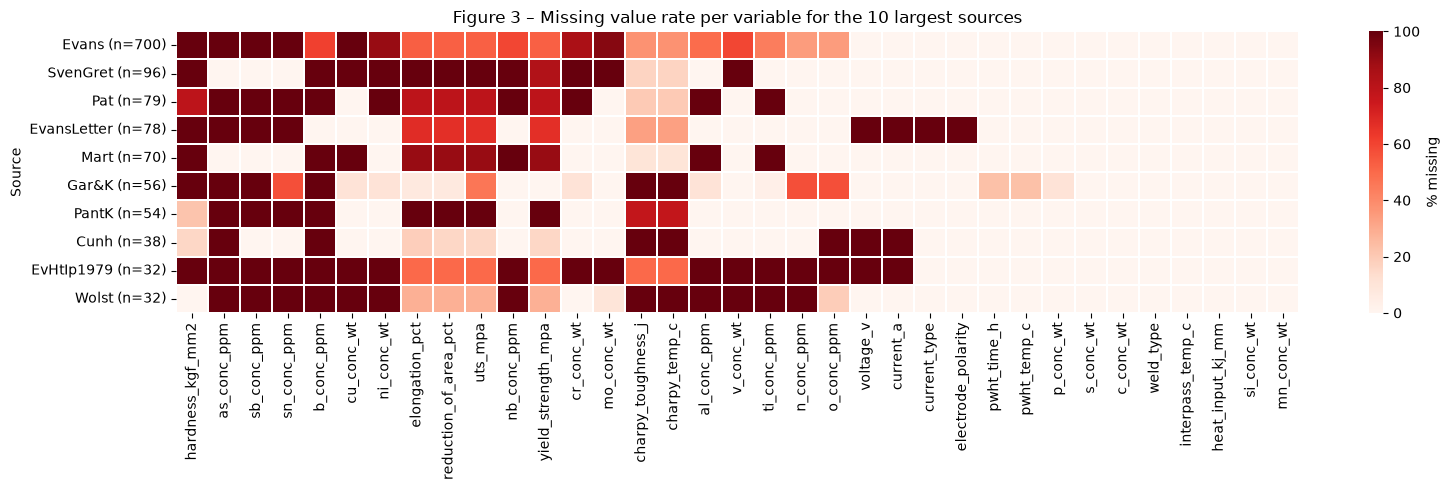

In [5]:
import seaborn as sns

top_sources = df["source"].value_counts().index[:10]

# Columns dropped: near-100% missing for every source (uninformative, washes out the contrast)
excluded_cols = [
    "fatt50_temp_c", "w_conc_wt", "martensite_pct", "ferrite_carbide_aggregate_pct",
    "ferrite_second_phase_pct", "acicular_ferrite_pct", "primary_ferrite_pct", "co_conc_wt",
]

# Same column order as Figure 1 (from most to least missing overall), minus the excluded block
column_order = [c for c in missing_rate.index if c in missing_by_source.columns and c not in excluded_cols]
data = missing_by_source.loc[top_sources, column_order]

# Row labels with the number of welds per source (context for each percentage)
counts = df["source"].value_counts()
data.index = [f"{s} (n={counts[s]})" for s in data.index]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(data, cmap="Reds", vmin=0, vmax=100,
            cbar_kws={"label": "% missing"}, linewidths=0.3, ax=ax)
ax.set_title("Figure 3 – Missing value rate per variable for the 10 largest sources")
ax.set_xlabel("")
ax.set_ylabel("Source")
plt.tight_layout()
fig.savefig(FIGURE_SUBDIRS["missingness"] / "fig3_missing_rate_by_source.png", dpi=150)
plt.show()

**Finding.** Missingness is not random: it strongly depends on the source publication (e.g. `Wolst` never reports hardness, `EvansLetter` never reports Ni/Cr/Mo/Cu). Columns that are nearly always missing (microstructure, `fatt50_temp_c`, `w_conc_wt`, `co_conc_wt`) were excluded from the figure since they sit at ~100% missing for every source, adding no contrast and drowning out the rest. This "per-study" missingness pattern (structural MNAR) should guide imputation: impute per source, or model the source indicator, rather than a naive global imputation.

### 2.4 Columns to exclude from modeling

In [6]:
# Columns with 92-98% missing overall: too few observations (30-140 rows) to be reliable
# model features. We keep them in the DataFrame (useful for mechanistic/exploratory analysis,
# e.g. microstructure as an intermediate variable) but exclude them from the default feature set.
excluded_from_modeling = [
    "fatt50_temp_c", "w_conc_wt", "martensite_pct", "ferrite_carbide_aggregate_pct",
    "ferrite_second_phase_pct", "acicular_ferrite_pct", "primary_ferrite_pct", "co_conc_wt",
]

print(missing_rate.loc[excluded_from_modeling].round(1).to_string())

fatt50_temp_c                    98.1
w_conc_wt                        95.5
martensite_pct                   94.6
ferrite_carbide_aggregate_pct    94.6
ferrite_second_phase_pct         94.6
acicular_ferrite_pct             94.6
primary_ferrite_pct              94.1
co_conc_wt                       92.2


**Finding.** These 8 columns sit at 92-98% missing overall (30-138 non-missing rows out of 1652). Rather than dropping them from the DataFrame, we exclude them from the default model feature set (`excluded_from_modeling`) and keep them available for targeted exploratory or mechanistic analysis — microstructure in particular is likely an intermediate variable between composition/process and mechanical properties, so it is worth keeping accessible even though it can't be a reliable input feature.

## 3. Target variable availability

In [7]:
targets = ["yield_strength_mpa", "uts_mpa", "elongation_pct", "reduction_of_area_pct",
           "charpy_toughness_j", "hardness_kgf_mm2", "fatt50_temp_c"]

presence = df[targets].notna()
print("\nNon-missing rows per target:")
print(presence.sum().sort_values(ascending=False).to_string())

print("\nNumber of targets available per row:")
print(presence.sum(axis=1).value_counts().sort_index().to_string())


Non-missing rows per target:
charpy_toughness_j       879
yield_strength_mpa       780
uts_mpa                  738
reduction_of_area_pct    705
elongation_pct           700
hardness_kgf_mm2         138
fatt50_temp_c             31

Number of targets available per row:
0     51
1    836
2     37
3     67
4    456
5    194
6     11


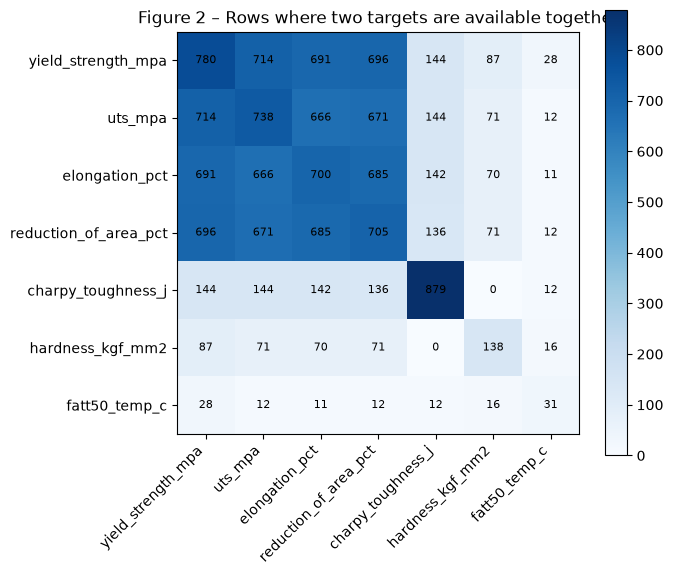

In [8]:
# Co-occurrence: number of rows where targets i AND j are both available
co_occurrence = presence.astype(int).T @ presence.astype(int)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(co_occurrence, cmap="Blues")
ax.set_xticks(range(len(targets)), targets, rotation=45, ha="right")
ax.set_yticks(range(len(targets)), targets)
for i in range(len(targets)):
    for j in range(len(targets)):
        ax.text(j, i, co_occurrence.iloc[i, j], ha="center", va="center", fontsize=8)
ax.set_title("Figure 2 – Rows where two targets are available together")
plt.colorbar(im)
plt.tight_layout()
fig.savefig(FIGURE_SUBDIRS["targets"] / "fig2_target_co_occurrence.png", dpi=150)
plt.show()

**Finding.** `charpy_toughness_j` (879), `yield_strength_mpa` (780), `uts_mpa` (738), `reduction_of_area_pct` (705), and `elongation_pct` (700) are the best-covered targets. `hardness_kgf_mm2` (138) and `fatt50_temp_c` (31) are too sparse for a robust model. 456 rows have 4 targets available simultaneously and 194 have 5: a solid base for a multi-output model on the 5 main mechanical properties.

## 4. Correlation analysis

**Caveat.** The cells below use a temporary numeric copy `num` in which non-numeric strings identified in section 1 (`<5`, `150-200`, mixed hardness units, ...) are coerced to NaN. This loses information — a value like `<5` does not mean "unknown". Once the censored columns have been cleaned, replace `num` with the cleaned DataFrame.

### 4.A Univariate distributions

                                  n   skew  n_unique  top_value_share_pct
p_conc_wt                      1642  10.82        35                13.03
s_conc_wt                      1641   9.65        33                24.56
martensite_pct                   89   9.43         2                98.88
sn_conc_ppm                     291   8.60        18                19.93
co_conc_wt                      108   5.45        12                53.70
w_conc_wt                        63   4.22         6                90.48
ferrite_carbide_aggregate_pct    89   3.62         8                87.64
voltage_v                      1404   2.83        24                51.14
cu_conc_wt                      564   2.73        74                34.40
n_conc_ppm                     1183   2.71       153                 3.21
ti_conc_ppm                     865   2.55        87                 9.94
ni_conc_wt                      697   2.41       101                31.85
heat_input_kj_mm               1652   

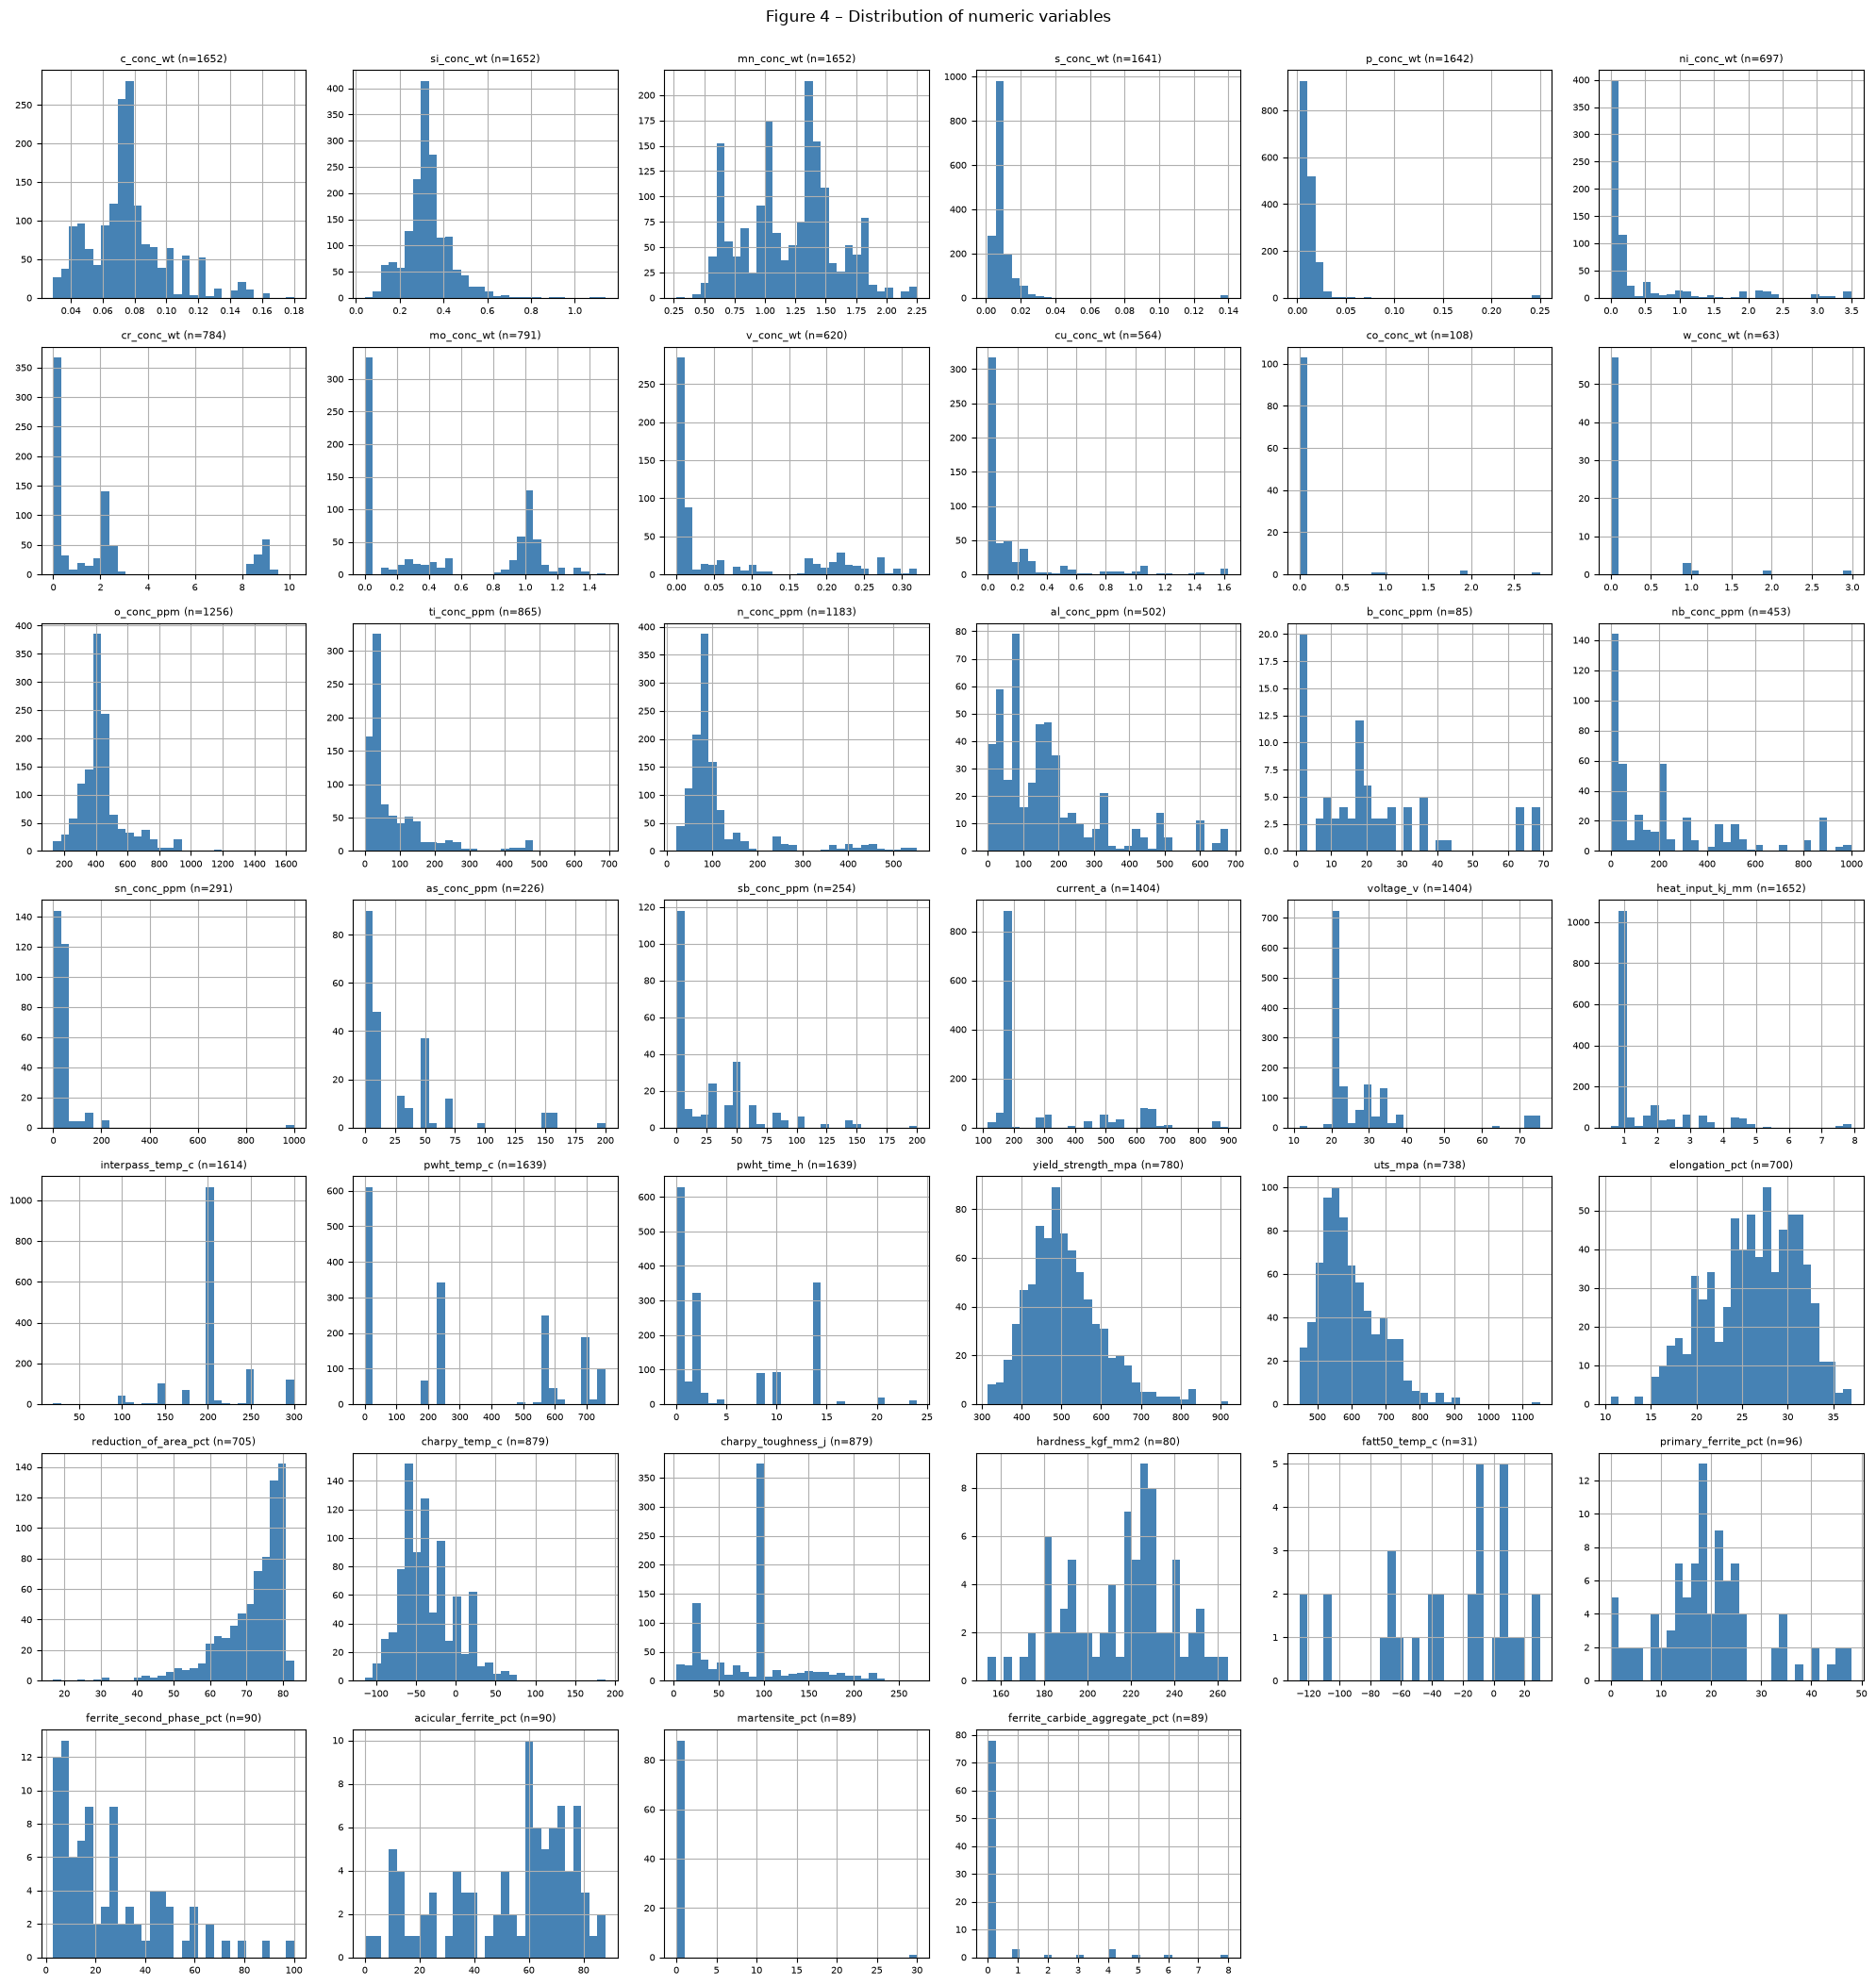

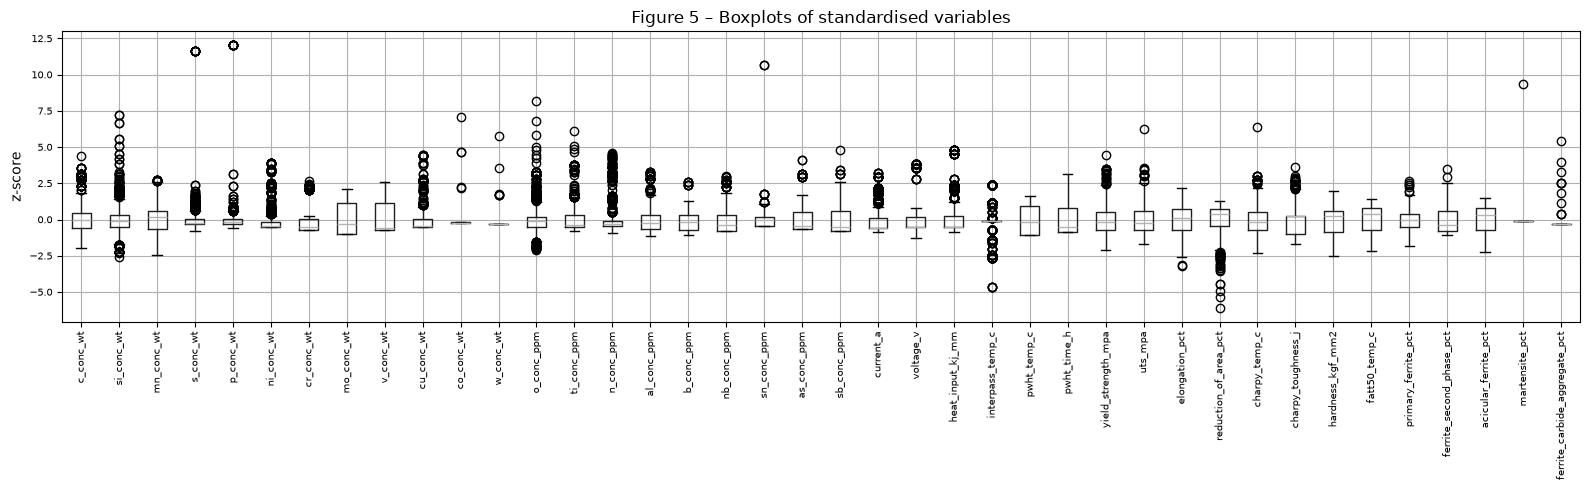

In [9]:
# Temporary numeric copy: non-numeric strings ("<5", "150-200", ...) become NaN.
# Replace this with your own cleaned DataFrame once you have decided how to treat them.
text_columns = ["current_type", "electrode_polarity", "weld_type", "weld_id", "source"]
num = df.drop(columns=text_columns).apply(pd.to_numeric, errors="coerce")

# Summary table: count, skewness, number of distinct values, share of the most frequent value
summary = pd.DataFrame({
    "n": num.notna().sum(),
    "skew": num.skew(),
    "n_unique": num.nunique(),
    "top_value_share_pct": num.apply(
        lambda s: s.value_counts(normalize=True).iloc[0] * 100 if s.notna().any() else np.nan),
})
print(summary.round(2).sort_values("skew", key=abs, ascending=False).to_string())

# Histograms of all numeric variables
n_cols = 6
n_rows = int(np.ceil(num.shape[1] / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3 * n_rows))
for ax, col in zip(axes.flat, num.columns):
    num[col].dropna().hist(ax=ax, bins=30, color="steelblue")
    ax.set_title(f"{col} (n={num[col].notna().sum()})", fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes.flat[num.shape[1]:]:
    ax.set_visible(False)
fig.suptitle("Figure 4 – Distribution of numeric variables", y=1.0)
plt.tight_layout()
fig.savefig(FIGURE_SUBDIRS["distributions"] / "fig4_histograms.png", dpi=150)
plt.show()

# Boxplots on standardised values, to compare outliers across variables with different units
standardised = (num - num.mean()) / num.std()
fig, ax = plt.subplots(figsize=(16, 5))
standardised.boxplot(ax=ax, rot=90, fontsize=7)
ax.set_ylabel("z-score")
ax.set_title("Figure 5 – Boxplots of standardised variables")
plt.tight_layout()
fig.savefig(FIGURE_SUBDIRS["distributions"] / "fig5_boxplots_standardised.png", dpi=150)
plt.show()

**What to look for.**
- *Strong skew* (|skew| > 1): often the case for impurity concentrations — many small values and a long tail. Decision: would a log transform help for linear models and PCA?
- *Extreme values* in the boxplots: data entry error, or a genuinely different steel (e.g. highly alloyed)? Check the underlying rows before dropping anything — in welding, an extreme point is often a real material family.
- *Near-constant variables* (`top_value_share_pct` close to 100, very low `n_unique`): candidates for removal. Cross-check with their `n`.
- *Multimodal histograms* (several bumps): suggests sub-populations, e.g. several welding types or sources. Keep this in mind for PCA.

**Your conclusions:**

- **Right-skewed impurities**: `s_conc_wt`, `p_conc_wt`, `co_conc_wt`, `w_conc_wt`, `cu_conc_wt`, `sn/b/as_conc_ppm` — spike near zero, long sparse tail. Try a log(1p) transform before linear models/PCA.
- **Structural multimodality**: `mn_conc_wt` (3 bumps, likely distinct steel grades), `cr/mo/v_conc_wt` (bimodal: unalloyed vs. alloyed — Cr≈9 cluster suggests a heat-resistant Cr-Mo family), `interpass_temp_c`/`pwht_temp_c`/`pwht_time_h` (narrow spikes at fixed WPS values, effectively categorical). A derived "alloy family" feature may beat the raw continuous values.
- **`charpy_toughness_j`** has a sharp artificial-looking spike near 100 J — check if it's a test ceiling/placeholder before trusting it as a clean target.
- **Near-constant / low-n candidates for removal**: `co_conc_wt`, `w_conc_wt`, `as_conc_ppm` — small `n` and one bin dominates.
- **Targets**: yield_strength/UTS mildly right-skewed (high-alloy tail), elongation fairly symmetric, `reduction_of_area_pct` capped near 80% (left-skewed — plain OLS is a poor fit without a transform).
- **Outliers (Fig. 5)**: extreme z-scores (P, S, Sn, N, Ti, O, ferrite_carbide/martensite) match the impurities flagged above — likely genuine rare values, not errors, but spot-check rows before any decision. `reduction_of_area_pct` has strong negative outliers; one `interpass_temp_c` point at z≈-5 worth checking.
- **Caveat**: analysis runs on `num`, where censored values (`<0.01`, etc.) are NaN — skew/outliers on impurity columns are likely *underestimated*. Re-run after cleaning those columns.

### 4.B Global correlation matrices (Pearson, Spearman, sample sizes)

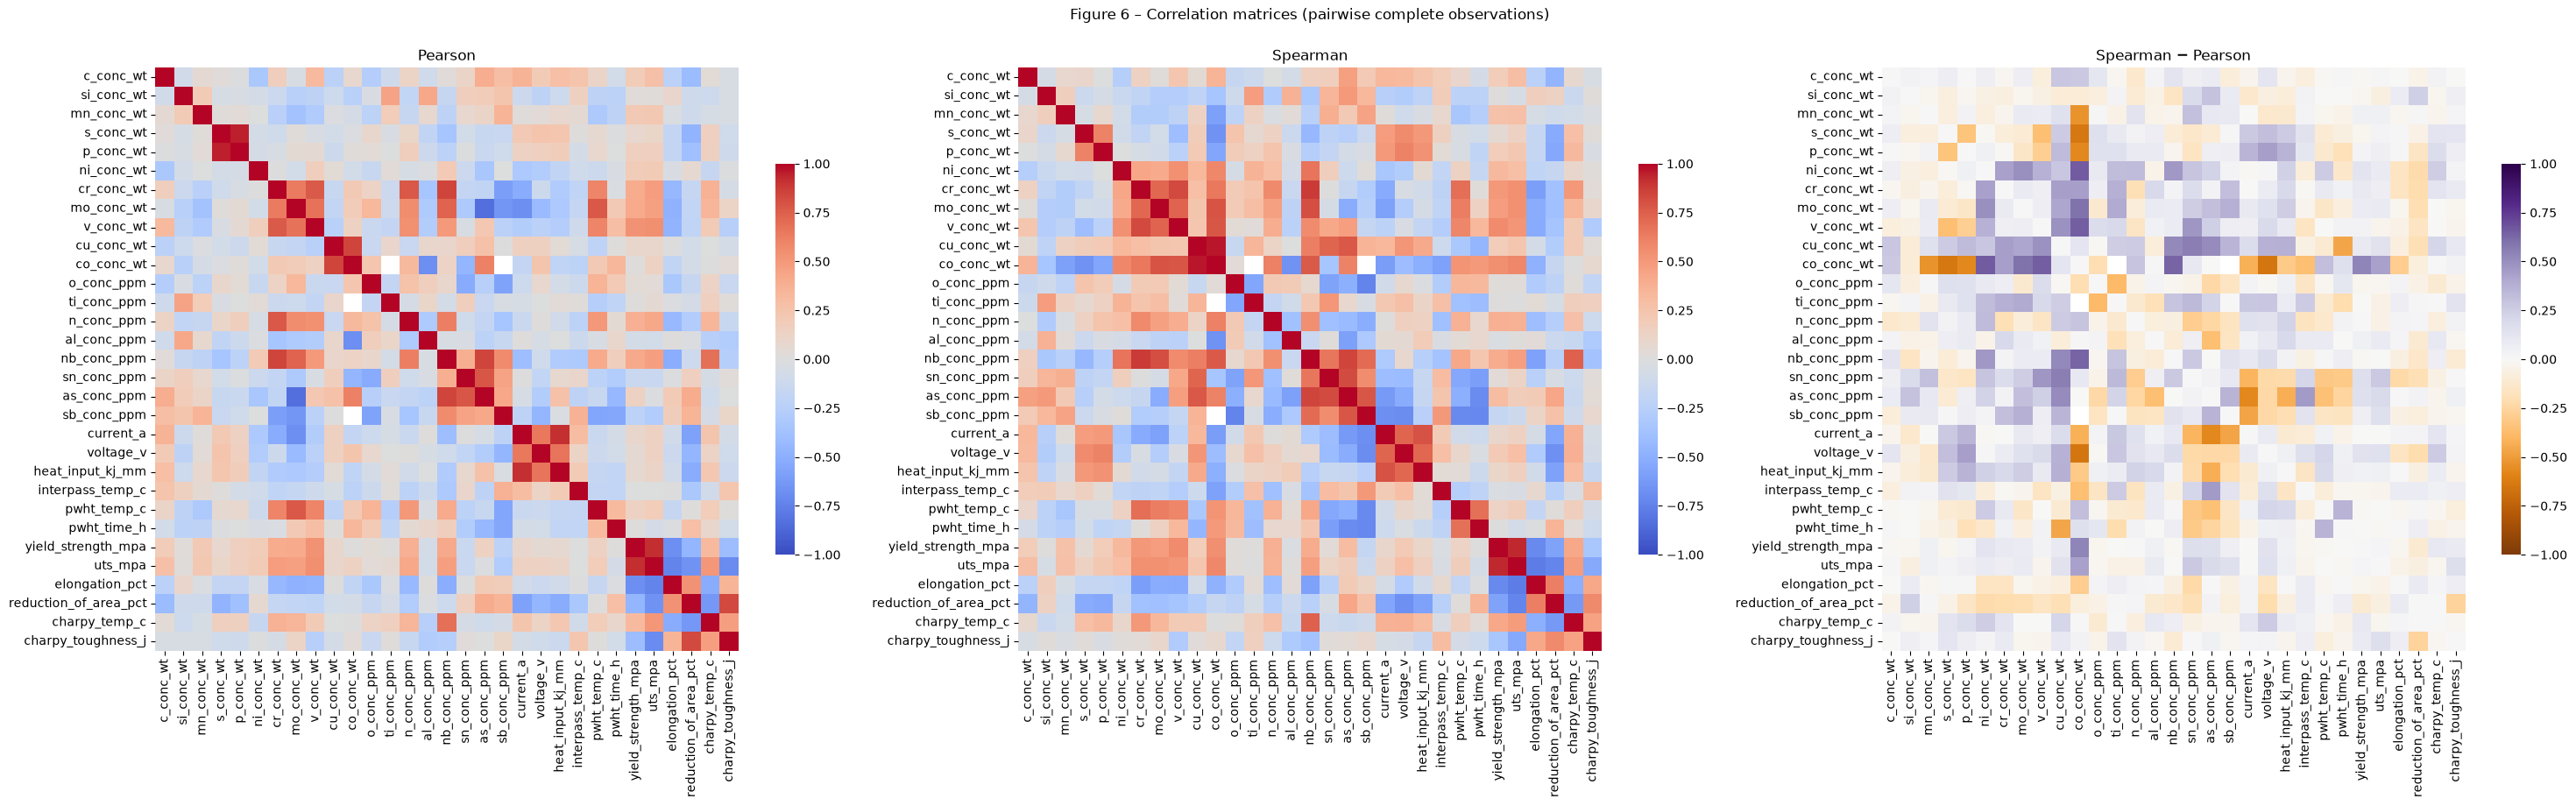

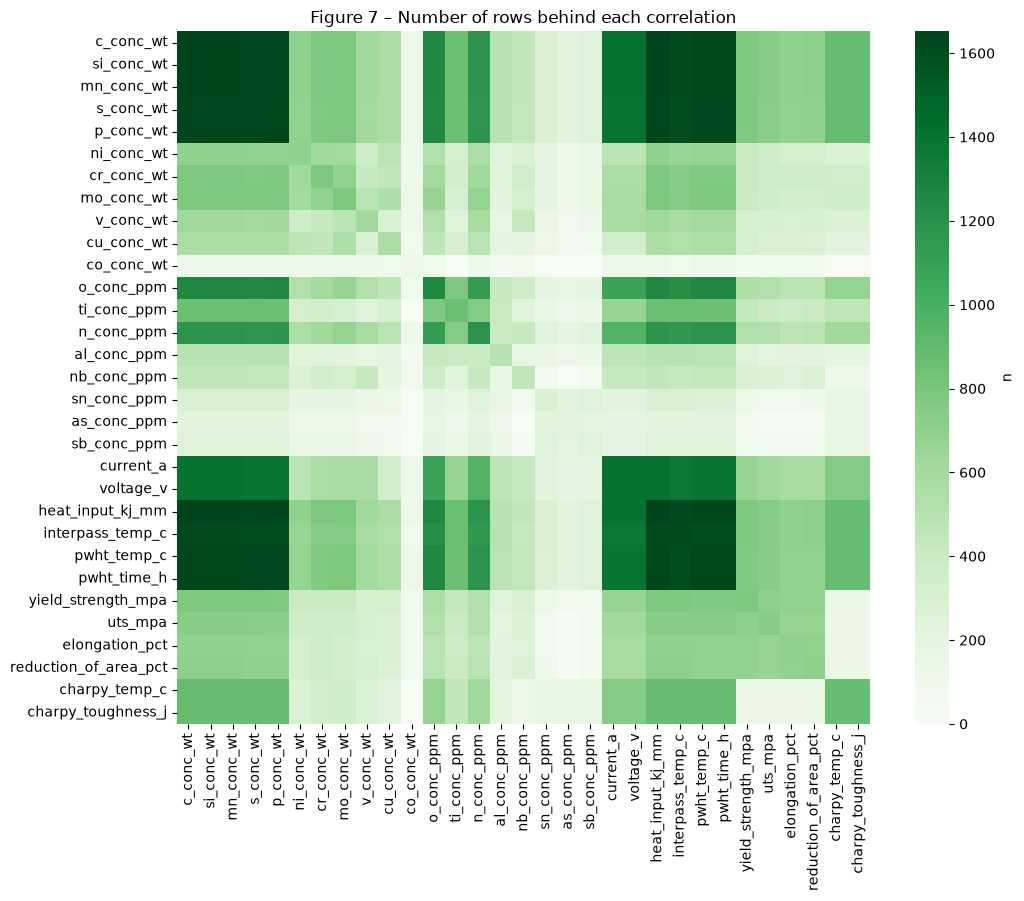

In [10]:
# Keep only variables with enough data to compute meaningful correlations
min_count = 100
num_corr = num.loc[:, num.notna().sum() >= min_count]

pearson = num_corr.corr(method="pearson")
spearman = num_corr.corr(method="spearman")

# Pairwise sample size: number of rows where both variables are available
available = num_corr.notna().astype(int)
pair_counts = available.T @ available

fig, axes = plt.subplots(1, 3, figsize=(30, 9))
for ax, matrix, title, cmap in [
    (axes[0], pearson, "Pearson", "coolwarm"),
    (axes[1], spearman, "Spearman", "coolwarm"),
    (axes[2], spearman - pearson, "Spearman − Pearson", "PuOr"),
]:
    sns.heatmap(matrix, cmap=cmap, vmin=-1, vmax=1, center=0, square=True,
                cbar_kws={"shrink": 0.6}, ax=ax)
    ax.set_title(title)
fig.suptitle("Figure 6 – Correlation matrices (pairwise complete observations)")
plt.tight_layout()
fig.savefig(FIGURE_SUBDIRS["correlations"] / "fig6_correlation_matrices.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(pair_counts, cmap="Greens", square=True, cbar_kws={"label": "n"}, ax=ax)
ax.set_title("Figure 7 – Number of rows behind each correlation")
plt.tight_layout()
fig.savefig(FIGURE_SUBDIRS["correlations"] / "fig7_pairwise_sample_sizes.png", dpi=150)
plt.show()

**What to look for.**
- Where Spearman and Pearson diverge, the relationship is non-linear but monotonic, or Pearson is being pulled by a few extreme values. This is an argument for non-linear models, or for transforming variables.
- Figure 7 is the most important of the three. It tells you which coefficients rest on thousands of rows and which rest on a few dozen. A strong coefficient with a small n is not a conclusion.

**Your conclusions:**

- **Three reliability tiers (Fig. 7)**: solid core (n≈1400-1650: base composition, process params, O/Ti/N) → trust at face value; medium tier (n≈500-800: Ni/Cr/Mo/V/Cu, main targets) → indicative only; fragile tier (n<300, often <150: Al/Nb/Sn/As/Sb, anything × `charpy_toughness_j`) → treat as hypotheses, not findings. `co_conc_wt` was dropped entirely (n<100).
- **Pearson ≈ Spearman overall** — the two matrices look like near-mirror images, so most relationships are roughly linear/monotonic. Divergence is concentrated, not scattered.
- **Where it concentrates**: `co_conc_wt`, `n_conc_ppm`, `sn/as/sb_conc_ppm`, `current_a`, `voltage_v` (|diff| > ~0.5). Matches 4.A's skewed-impurity and multimodal-process-variable findings — Pearson is likely pulled by extreme values/off-cluster points there. Argument for Spearman or log transform on these specific columns.
- **But check n first**: `co_conc_wt`/`sn/as/sb` sit in the fragile tier, so their divergence may be small-sample noise rather than real non-linearity. `current_a`/`voltage_v` sit in the solid core, so their divergence is more likely genuine — worth transforming.
- **Clean zone**: the 4 main targets (yield_strength, UTS, elongation, reduction_of_area) and base composition (C/Si/Mn/S/P) vs targets show little Pearson/Spearman gap — consistent with known, roughly linear metallurgical effects.

### 4.C Correlations by block (inputs vs inputs, targets vs targets, inputs vs targets)

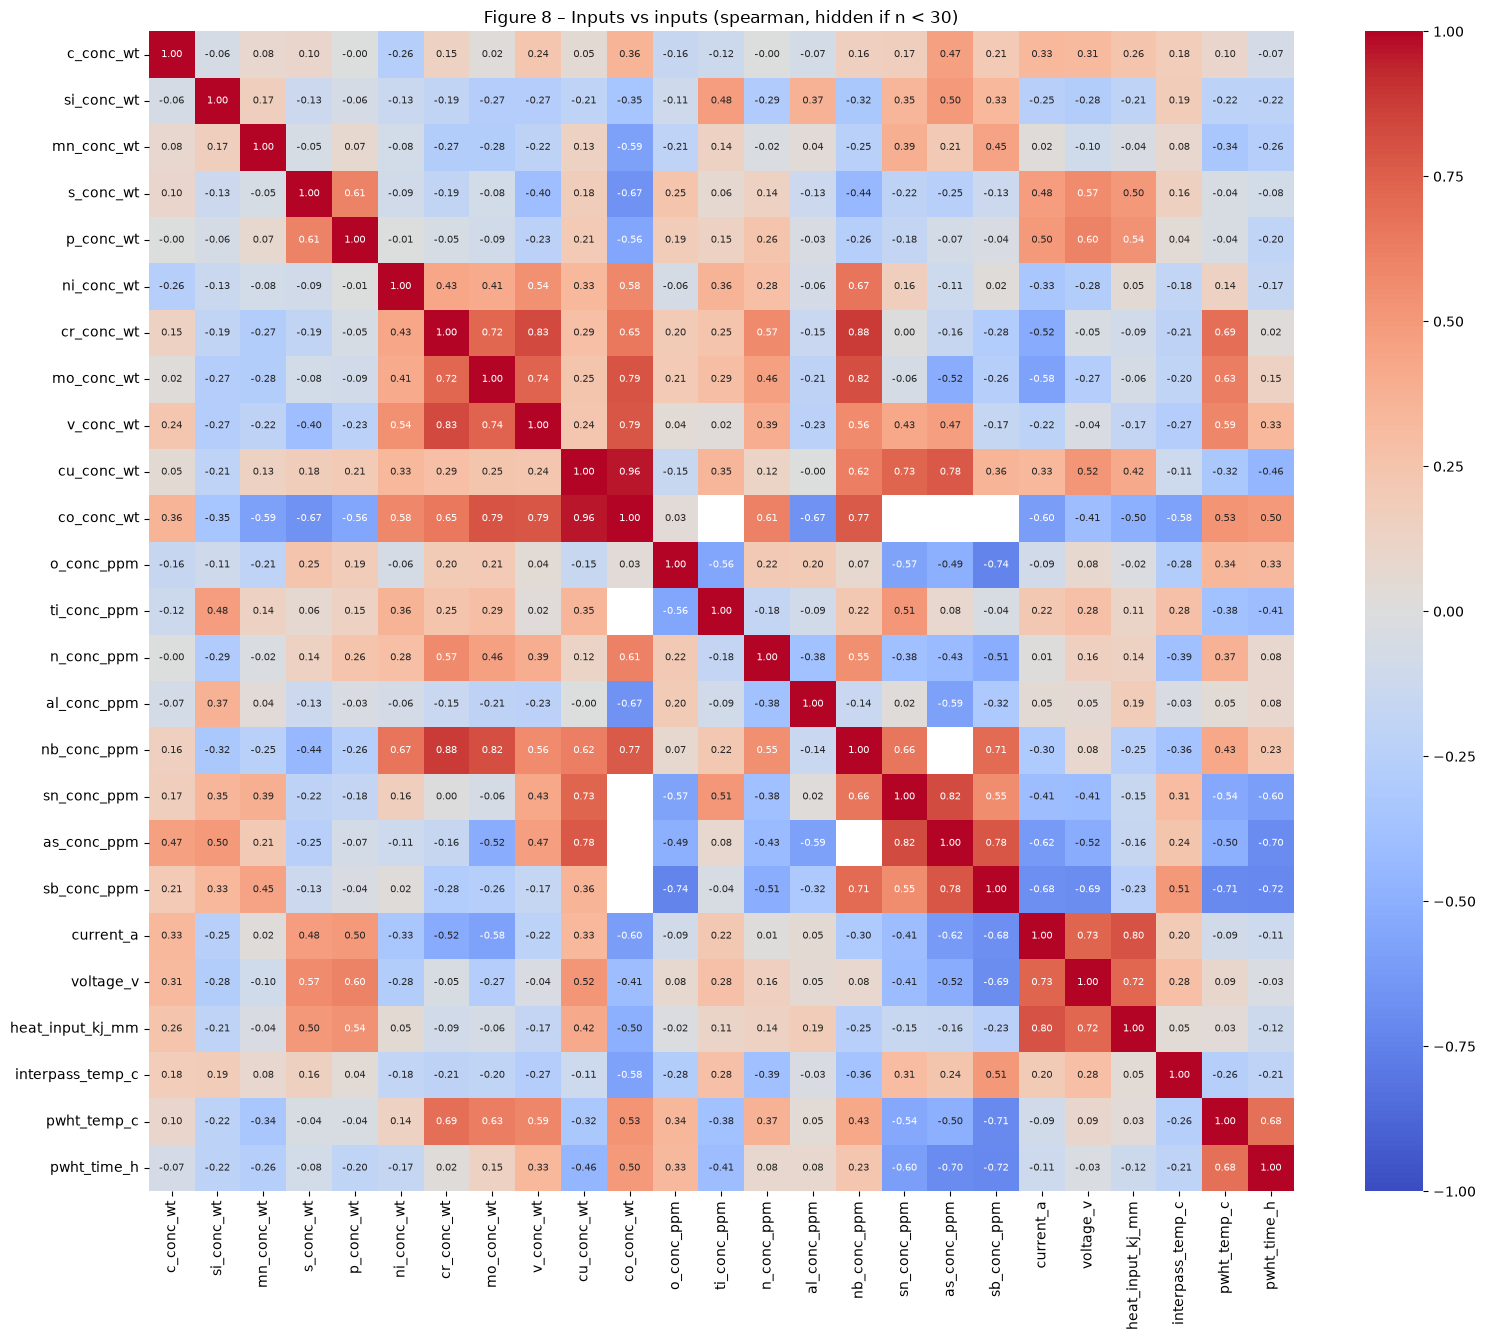

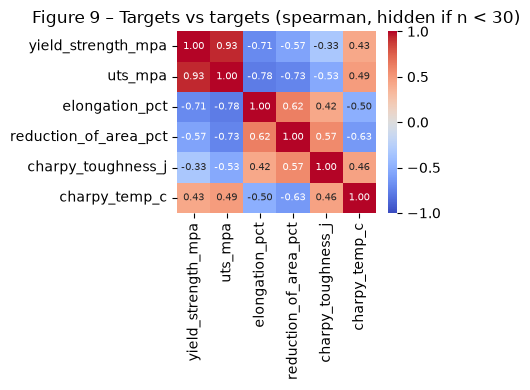

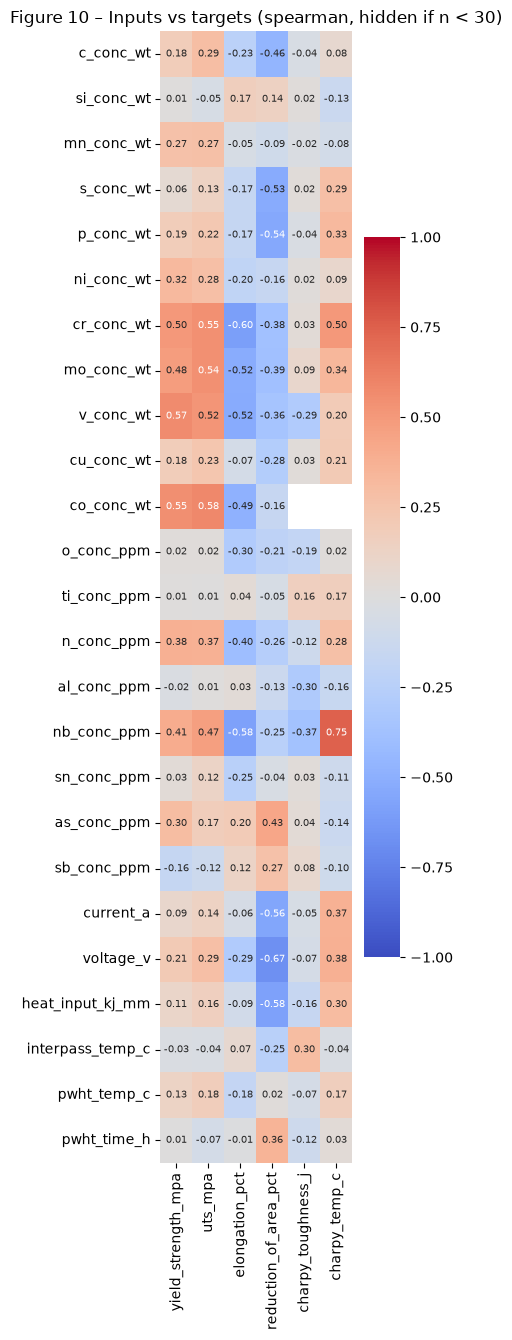

                                         rho    n  abs_rho
nb_conc_ppm      charpy_temp_c          0.75  133     0.75
voltage_v        reduction_of_area_pct -0.67  592     0.67
cr_conc_wt       elongation_pct        -0.60  357     0.60
heat_input_kj_mm reduction_of_area_pct -0.58  705     0.58
co_conc_wt       uts_mpa                0.58   75     0.58
nb_conc_ppm      elongation_pct        -0.58  258     0.58
v_conc_wt        yield_strength_mpa     0.57  321     0.57
current_a        reduction_of_area_pct -0.56  592     0.56
co_conc_wt       yield_strength_mpa     0.55   74     0.55
cr_conc_wt       uts_mpa                0.55  372     0.55
mo_conc_wt       uts_mpa                0.54  350     0.54
p_conc_wt        reduction_of_area_pct -0.54  699     0.54
s_conc_wt        reduction_of_area_pct -0.53  701     0.53
v_conc_wt        elongation_pct        -0.52  300     0.52
                 uts_mpa                0.52  311     0.52


In [11]:
target_cols = [c for c in targets + ["charpy_temp_c"] if c in num_corr.columns]
input_cols = [c for c in num_corr.columns
              if c not in target_cols and c not in [
                  "primary_ferrite_pct", "ferrite_second_phase_pct", "acicular_ferrite_pct",
                  "martensite_pct", "ferrite_carbide_aggregate_pct"]]

def plot_block(rows, cols, title, filename, method="spearman", min_pairs=30):
    """Correlation heatmap for a block, hiding coefficients computed on too few rows."""
    all_cols = list(dict.fromkeys(rows + cols))          # avoid duplicated columns
    corr = num_corr[all_cols].corr(method=method).loc[rows, cols]
    counts = pair_counts.loc[rows, cols]
    fig, ax = plt.subplots(figsize=(1 + 0.6 * len(cols), 1 + 0.5 * len(rows)))
    sns.heatmap(corr, mask=counts < min_pairs, cmap="coolwarm", vmin=-1, vmax=1,
                annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax)
    ax.set_title(f"{title} ({method}, hidden if n < {min_pairs})")
    plt.tight_layout()
    fig.savefig(FIGURE_SUBDIRS["correlations"] / filename, dpi=150)
    plt.show()
    return corr, counts

corr_in_in, n_in_in = plot_block(input_cols, input_cols, "Figure 8 – Inputs vs inputs", "fig8_inputs_vs_inputs.png")
corr_out_out, n_out_out = plot_block(target_cols, target_cols, "Figure 9 – Targets vs targets", "fig9_targets_vs_targets.png")
corr_in_out, n_in_out = plot_block(input_cols, target_cols, "Figure 10 – Inputs vs targets", "fig10_inputs_vs_targets.png")

# Ranked list of input–target pairs, with the sample size behind each coefficient
ranking = (pd.DataFrame({"rho": corr_in_out.stack(), "n": n_in_out.stack()})
             .query("n >= 30")
             .assign(abs_rho=lambda d: d["rho"].abs())
             .sort_values("abs_rho", ascending=False))
print(ranking.head(15).round(2).to_string())

**What to look for.**
- *Inputs vs inputs*: spot redundancies. Process parameters linked by construction (current, voltage, heat input) or elements that vary together are a multicollinearity problem for linear models, and also what PCA will summarize.
- *Targets vs targets*: look for the strength / ductility / toughness trade-off. If two targets are highly correlated, do you really need two models? If they're opposed, that justifies not collapsing them into a single score.
- *Inputs vs targets*: these are your first predictive hypotheses, but only hypotheses. For each pair in the ranking, check it against metallurgy (a known effect for that element?) and check its `n`.

**Your conclusions:**

- **Inputs vs inputs (Fig. 8)**: heavy redundancy in the alloying block — `cr/mo/v/nb_conc_wt` intercorrelated (ρ 0.72–0.88), `cu_conc_wt`/`co_conc_wt` near-identical (ρ=0.96). `current_a`/`voltage_v`/`heat_input_kj_mm` also correlated (ρ 0.72–0.80), expected since heat input is derived from the other two. Real multicollinearity risk for linear models; PCA will likely collapse these into 1-2 "alloy family" components rather than keep them independent.
- **Targets vs targets (Fig. 9)**: clear strength/ductility/toughness trade-off. `yield_strength_mpa`/`uts_mpa` near-redundant (ρ=0.93). Both strongly *negatively* tied to `elongation_pct` (-0.71/-0.78) and `reduction_of_area_pct` (-0.57/-0.73) — stronger welds are less ductile. `charpy_toughness_j` tracks ductility (+0.57 to +0.62) and opposes strength. Targets aren't independent → don't collapse into one score; expect a multi-output model to trade off.
- **Inputs vs targets (Fig. 10)**, ranked by how much to trust them:
  - *Solid*: `voltage_v`/`heat_input_kj_mm`/`current_a` vs `reduction_of_area_pct` (ρ -0.56 to -0.67) and `s/p_conc_wt` vs `reduction_of_area_pct` (ρ≈-0.53/-0.54) — high n (Fig. 7), metallurgically expected (S/P are classic embrittling impurities). Best first features.
  - *Plausible*: `cr/mo/v/nb_conc_wt` vs elongation (-0.52 to -0.60) and vs yield/UTS (0.41-0.57) — medium n, consistent with the strength-ductility trade-off above.
  - *Suspect*: `nb_conc_ppm` vs `charpy_temp_c` (ρ=0.75, the single strongest coefficient) — Nb sits in the fragile n-tier and `charpy_temp_c` is a test condition, not a material property, so this smells like a protocol artifact (Nb welds tested at different temperatures) rather than metallurgy. `co_conc_wt` vs yield/UTS (ρ≈0.55-0.58) is likely just proxying `cu_conc_wt` (ρ=0.96 with it in Fig. 8) on very few rows.
- **Next**: verify the Nb/charpy_temp_c and Co/strength pairs with scatter plots (4.D), colored by `source`/`weld_type`, before trusting them.

### 4.D Scatter plots for pairs of interest

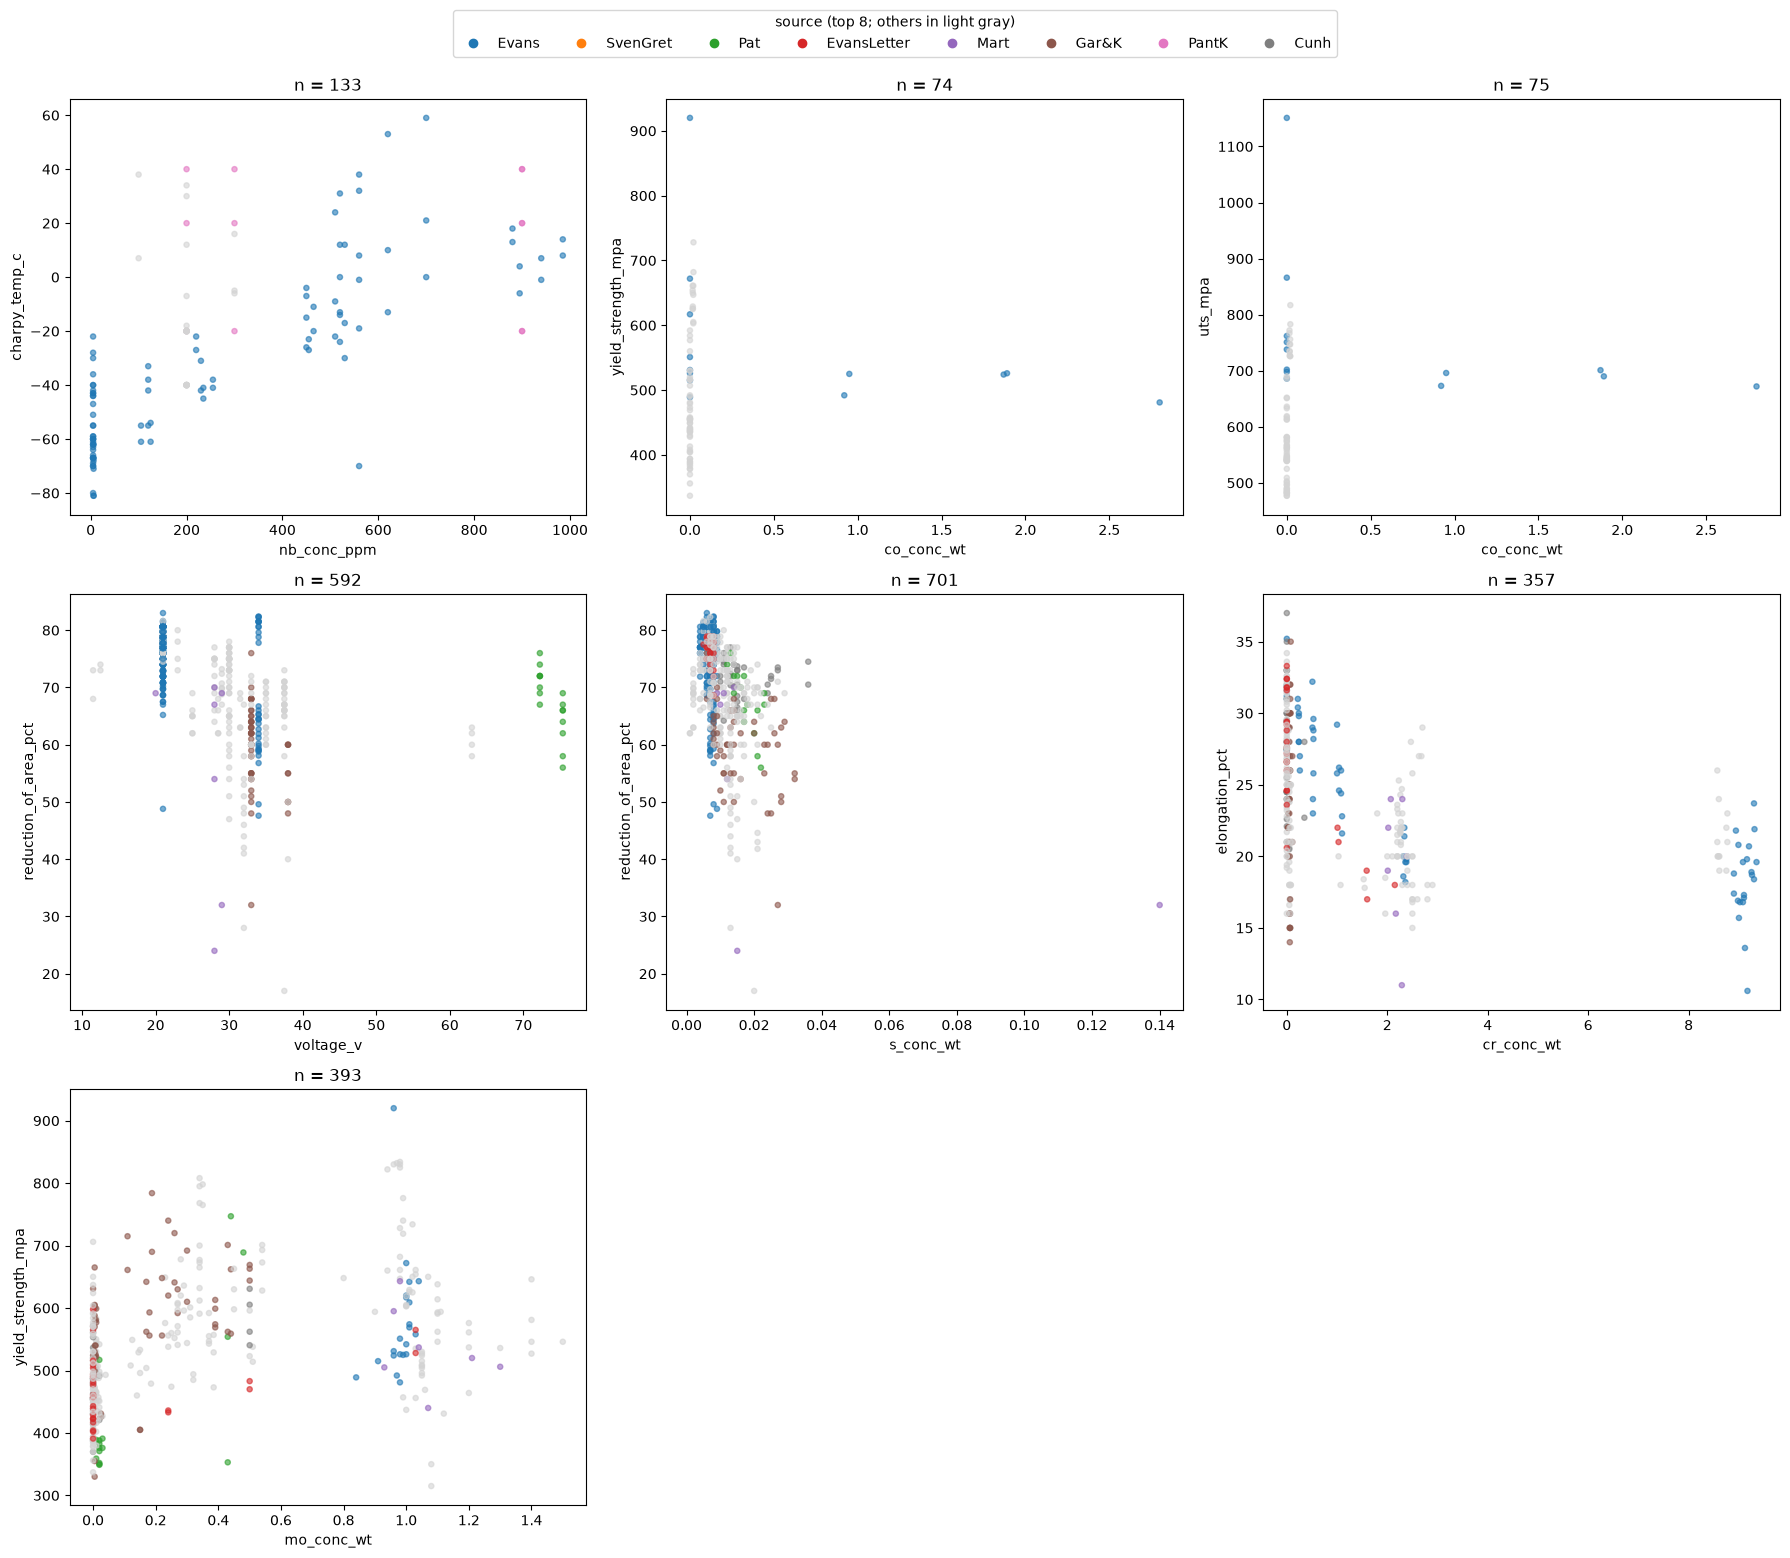

In [12]:
pairs_to_check = [
    # Suspect (4.C): possible protocol/database-assembly artifacts
    ("nb_conc_ppm", "charpy_temp_c"),
    ("co_conc_wt", "yield_strength_mpa"),
    ("co_conc_wt", "uts_mpa"),
    # Solid (4.C): high-n, metallurgically expected
    ("voltage_v", "reduction_of_area_pct"),
    ("s_conc_wt", "reduction_of_area_pct"),
    # Plausible (4.C): medium-n, consistent with the strength-ductility trade-off
    ("cr_conc_wt", "elongation_pct"),
    ("mo_conc_wt", "yield_strength_mpa"),
]

top_sources = df["source"].value_counts().index[:8]
palette = dict(zip(top_sources, plt.cm.tab10.colors))

n_cols = 3
n_rows = int(np.ceil(len(pairs_to_check) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
for ax, (x, y) in zip(np.atleast_1d(axes).flat, pairs_to_check):
    subset = num[[x, y]].join(df["source"]).dropna(subset=[x, y])
    colors = subset["source"].map(palette).fillna("lightgray")
    ax.scatter(subset[x], subset[y], s=14, alpha=0.6, c=colors)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"n = {len(subset)}")
for ax in np.atleast_1d(axes).flat[len(pairs_to_check):]:
    ax.set_visible(False)

handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=s)
           for s, c in palette.items()]
fig.legend(handles=handles, loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 1.04),
           title="source (top 8; others in light gray)")
plt.tight_layout()
fig.savefig(FIGURE_SUBDIRS["correlations"] / "fig_scatter_pairs_of_interest.png", dpi=150, bbox_inches="tight")
plt.show()

**What to look for.** Is the cloud homogeneous, or made of separate clusters? Distinct clusters often mean the correlation comes from a gap *between* groups (sources, weld types) rather than a relationship *within* groups. Coloring points by `source` or `weld_type` reveals this immediately.

**Recurring question.** This database is a compilation of studies, each with its own protocol. Part of the correlations therefore reflects who measured what, and under which conditions, rather than the physics of welding. In your ranking, look for a strong correlation that makes no physical sense. What explanation related to how the database was assembled could you propose?

**Your conclusions:**

All 7 pairs replotted with points colored by `source` (top 8 sources; all others in light gray).

- **`nb_conc_ppm` vs `charpy_temp_c` (n=133) — confirmed artifact.** Almost every point is `Evans` (blue) or `PantK` (pink); no other source contributes meaningfully. Within `Evans` alone, higher Nb still tracks higher (less negative) test temperature, so this isn't purely a between-source offset — but since one study supplies nearly the whole signal, ρ=0.75 describes `Evans`'s testing protocol (which temperatures they chose to test at for which alloys), not a general metallurgical law. Answers the recurring question directly: a single dominant source can manufacture a strong "effect" that is really about how that lab designed its test matrix.
- **`co_conc_wt` vs yield_strength/UTS (n=74/75) — confirmed artifact, more starkly.** All non-zero Co values belong to `Evans` alone; every other source sits at Co≈0 (the gray/blue wall on the left). The apparent trend is 3-4 `Evans` points at moderate strength scattered at increasing Co — far too few to support ρ≈0.55-0.58, and no other source has any Co variation to compare against. This is essentially one study's alloy choices, not a population-level relationship. Confirms the 4.C suspicion.
- **`voltage_v` vs `reduction_of_area_pct` (n=592) — real, but source-structured.** Multiple sources overlap in the main 20-35V band (`Evans`, `Gar&K`, gray others), so this isn't a single-source artifact. But `Pat` (green) forms a visibly separate cluster around 70-75V with its own somewhat lower reduction-of-area level — a between-group offset sitting on top of a within-group trend. The correlation is a mix of genuine process effect and a source-specific voltage regime; worth checking whether `Pat` uses a different welding process entirely (e.g. a process with characteristically higher voltage).
- **`s_conc_wt` vs `reduction_of_area_pct` (n=701) — real, well-mixed.** Dense, multi-source cloud (`Evans`, `EvansLetter`, `Gar&K`, gray) with no visible separation by color — sources overlap thoroughly across the S range. This is the cleanest-looking relationship of the seven: a genuine, broadly-supported negative effect, consistent with S being a classic embrittling impurity.
- **`cr_conc_wt` vs `elongation_pct` (n=357) — real trend, but driven by an `Evans`-only sub-population.** The high-Cr cluster (~9 wt%) is almost entirely `Evans` (blue), while the low/zero-Cr mass mixes several sources. So part of the strength of this correlation comes from one source contributing the entire high-Cr regime — the low-Cr-to-mid-Cr trend across mixed sources looks real, but the full ρ, anchored by the Evans-only high-Cr cluster, likely overstates how generalizable the high-Cr effect is beyond that one study's alloy family.
- **`mo_conc_wt` vs `yield_strength_mpa` (n=393) — real, well-mixed, but noisy.** Good source mixing across the range (`Gar&K`, `EvansLetter`, `Evans`, gray all present at low and mid Mo), no obvious single-source cluster driving it. The relationship is genuine but weak/noisy — consistent with 4.C's "plausible, medium-n" tier rather than a strong effect.
- **Answering the recurring question directly**: the two `co_conc_wt` correlations and the `nb_conc_ppm`/`charpy_temp_c` correlation are the strong coefficients that make little physical sense once colored by source — in both cases a single study (`Evans`) supplies essentially all the variation in the input variable, so the "correlation" mostly encodes that lab's specific alloy/test choices rather than a metallurgical law. The database-assembly explanation: welddb pools independent studies that each explored a narrow, deliberately chosen slice of composition/process space, so any variable that only one study varied will correlate with whatever else that study also varied by construction, independent of any real causal link.
- **Practical implication**: `co_conc_wt` should not be trusted as a predictive feature without stratifying by source (or simply dropping it — it's already flagged in `excluded_from_modeling`-adjacent territory given n<100 in Fig. 7). `nb_conc_ppm`'s relationship with process/test variables needs a source-aware model (e.g. include `source` or a derived study/protocol indicator) rather than being taken at face value. `s_conc_wt` and `mo_conc_wt` vs their targets are the more trustworthy signals to carry into feature selection.

## First conclusions

1. **Drop the 92-98% missing columns from modeling, not from the dataset**: microstructure fractions, `fatt50_temp_c`, `w_conc_wt`, and `co_conc_wt` have too few observations (30-140 rows) to be reliable model features. They are kept in `df` for exploratory/mechanistic use but excluded from the default feature set via `excluded_from_modeling` (see 2.4).
2. **Cleaning is required before anything else**: 21 numeric columns are polluted by `<threshold` notation, ranges, or mixed units (Hv10/Hv30 hardness). Dedicated per-column parsing is a prerequisite.
3. **Target 5 mechanical properties**: `yield_strength_mpa`, `uts_mpa`, `elongation_pct`, `reduction_of_area_pct`, `charpy_toughness_j` are sufficiently populated for modeling; `hardness_kgf_mm2` and `fatt50_temp_c` are excluded from the main scope (too little data).
4. **Missingness is structural, not random**: it depends on the source publication. Imputation and validation must account for this (avoid source-related information leakage, consider stratifying by source).
5. **Next step**: clean the censored/mixed columns, then study target distributions and their correlations with chemical composition and welding parameters.
